In [42]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('dataset.csv')
df.head()

,name,gpa(1-4),communication(1-5),activities(1-5),discipline(1-5),teamwork(1-5)
0,Va,4,4,5,3,3
1,ni,3,3,4,4,3
2,vo,2,5,5,1,4
3,re,5,4,5,4,5
4,es,5,4,4,5,5


In [44]:
features = ['gpa(1-4)', 'communication(1-5)', 'activities(1-5)', 'discipline(1-5)', 'teamwork(1-5)']
x = df[features]
x.head()

,gpa(1-4),communication(1-5),activities(1-5),discipline(1-5),teamwork(1-5)
0,4,4,5,3,3
1,3,3,4,4,3
2,2,5,5,1,4
3,5,4,5,4,5
4,5,4,4,5,5


In [45]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [46]:
kmeans= KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(x_scaled)


In [47]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

In [48]:
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centers_2d = pca.transform(centers_df)

c:\Users\Mandy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


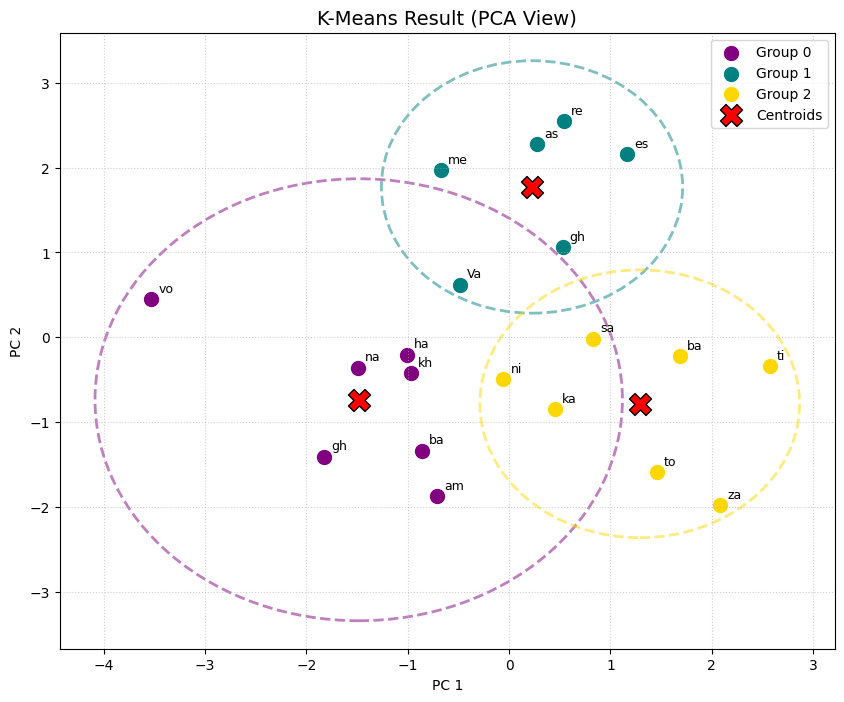

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['purple', 'teal', 'gold'] 
labels = df['cluster']

for i in range(3):
    points = X_pca[labels == i]
    ax.scatter(points[:, 0], points[:, 1], s=100, c=colors[i], label=f'Group {i}')

ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           marker='X', s=250, c='red', edgecolor='black', zorder=10, label='Centroids')

# رسم دایره‌ها
for i in range(3):
    points = X_pca[labels == i]
    center = centers_2d[i]
    if len(points) > 0:
        distances = np.linalg.norm(points - center, axis=1)
        radius = np.max(distances) * 1.1
    else:
        radius = 0.5
    circle = plt.Circle((center[0], center[1]), radius,
                        color=colors[i], fill=False, linestyle='--', linewidth=2, alpha=0.5)
    ax.add_patch(circle)

for i, txt in enumerate(df['name']):
    x_coord = X_pca[i, 0]
    y_coord = X_pca[i, 1]

    ax.annotate(txt,                     
                (x_coord, y_coord),      
                xytext=(5, 5),          
                textcoords='offset points', 
                fontsize=9)             
    

plt.title('K-Means Result (PCA View)', fontsize=14)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [50]:
print("\n" + "="*50)
print("       جدول تحلیل ویژگی‌های هر گروه (میانگین)")
print("="*50)
numeric_cols = features + ['cluster']
print(df[numeric_cols].groupby('cluster').mean())
print("="*50)


       جدول تحلیل ویژگی‌های هر گروه (میانگین)
         gpa(1-4)  communication(1-5)  activities(1-5)  discipline(1-5)  \
cluster                                                                   
0        2.857143            4.142857         3.142857         2.285714   
1        4.333333            4.000000         4.666667         4.166667   
2        4.000000            2.714286         2.857143         4.571429   

         teamwork(1-5)  
cluster                 
0             3.285714  
1             4.500000  
2             2.857143  
